# Nemotron-3 Super: Hybrid Mamba-Transformer MoE

This notebook replicates the architecture of **Nemotron-3 Super** (NVIDIA, 2026) — a 120B
total / 12B active-parameter model that combines **Mamba** (State Space Models) with
**Transformer attention** and **Mixture of Experts** into a hybrid architecture.

Nemotron-3 Super introduces concepts not covered elsewhere in this repo:
- **Mamba-2 layers** — O(N) sequence processing (vs O(N²) attention)
- **Hybrid Mamba-Transformer** — interleave SSM and attention in a 3:1 ratio
- **LatentMoE** — compress tokens before expert routing (4x more experts at same cost)
- **Native FP4 training** — 4-bit from the first gradient (beyond DeepSeek's FP8)
- **MTP with speculative decoding** — prediction heads double as a draft model
- **1M token context** — enabled by Mamba's linear complexity

**Reference:** NVIDIA (2026). *Nemotron-3 Super Technical Report.*
https://arxiv.org/abs/2512.20856

In [13]:
import sys, os
# In Colab, clone the repo so local imports (src/) work
if "google.colab" in str(get_ipython()):
    if not os.path.exists("/content/DeepLearning_101"):
        !git clone --depth 1 https://github.com/MaxiRuess/DeepLearning_101.git /content/DeepLearning_101
    os.chdir("/content/DeepLearning_101/notebooks/07_Model_Replications")
    sys.path.insert(0, "/content/DeepLearning_101")
else:
    sys.path.insert(0, os.path.abspath("../.."))

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
import time
import matplotlib.pyplot as plt
from src.utils.device import set_seed

set_seed(42)
print(f"PyTorch version: {torch.__version__}")

Set seed for reproducibility: 42
PyTorch version: 2.11.0


## 1. Architecture at a Glance

| | Nemotron-3 Super | DeepSeek-V3 | LLaMA 3 405B |
|---|---|---|---|
| Total params | 120B | 671B | 405B |
| Active params/token | 12B (10%) | 37B (5.5%) | 405B (100%) |
| Sequence processing | **Mamba-2 (SSM)** | Attention (MLA) | Attention (GQA) |
| Attention layers | Sparse (every 4th) | All layers | All layers |
| MoE type | **LatentMoE** | DeepSeekMoE | N/A (dense) |
| Training precision | **FP4** | FP8 | BF16 |
| Context length | **1M tokens** | 128K | 128K |
| Training tokens | 25T | 14.8T | 15T |

The key differentiator: Nemotron replaces most attention layers with **Mamba** (State Space
Model) layers that process sequences in O(N) time, enabling 1M-token context windows.

## 2. The Block Pattern

Nemotron-3 Super interleaves three layer types in a repeating pattern:

```
Block 1: Mamba-2      ← sequence processing (O(N), cheap)
Block 2: LatentMoE    ← sparse FFN (only top-K experts)
Block 3: Mamba-2      ← more sequence processing
Block 4: Attention     ← precise associative recall (O(N²), expensive)
Block 5: Mamba-2      ← more sequence processing
Block 6: LatentMoE    ← sparse FFN
... repeat ...
```

Ratio: **3 Mamba : 1 Attention : 2 MoE** per cycle. Mamba handles the bulk of
sequence processing; attention only appears at key depths for tasks that require
precise token-to-token lookup ("what was the 5th word?").

## 3. Why Mamba?

Self-attention computes all $N^2$ pairwise interactions:

| Sequence Length | Attention (O(N²)) | Mamba (O(N)) |
|---|---|---|
| 1K | 1M ops | 1K ops |
| 4K | 16M ops | 4K ops |
| 128K | 16B ops | 128K ops |
| **1M** | **1T ops** | **1M ops** |

At 1M tokens, attention is 1,000,000x more expensive per layer than Mamba.
This is why Nemotron can support 1M context — most layers are Mamba.

| | RNN | Attention | **Mamba (SSM)** |
|---|---|---|---|
| Training | Sequential (slow) | Parallel (fast) | **Parallel (fast)** |
| Inference | O(1) per step | O(N) per step | **O(1) per step** |
| Long-range | Weak (forgetting) | Strong (direct) | **Strong (selective)** |
| Complexity | O(N) | O(N²) | **O(N)** |

## 4. State Space Models (SSMs)

An SSM maps an input sequence $x(t)$ to an output $y(t)$ through a hidden state $h(t)$:

$h'(t) = Ah(t) + Bx(t)$

$y(t) = Ch(t)$

**Discretize** for digital computation (with step size $\Delta$):

$h_t = \bar{A}h_{t-1} + \bar{B}x_t$

$y_t = Ch_t$

where $\bar{A} = \exp(\Delta A)$ and $\bar{B} = (\Delta A)^{-1}(\exp(\Delta A) - I) \cdot \Delta B$.

This looks like an RNN — but with **structured** A, B, C matrices that enable
**parallel training** via convolution or associative scan.

## 5. Mamba's Innovation: Selective SSM

Classic SSMs use **fixed** A, B, C matrices (same for every input). Mamba makes them
**input-dependent** — the model can selectively remember or forget based on content:

$B_t = \text{Linear}_B(x_t)$

$C_t = \text{Linear}_C(x_t)$

$\Delta_t = \text{softplus}(\text{Linear}_\Delta(x_t))$

**Intuition:** When the model sees an important token, it can set $\Delta$ large
(big state update = remember). When it sees filler, it can set $\Delta$ small
(small update = forget/pass through). This is the "selection" mechanism.

In [2]:
class SelectiveSSM(nn.Module):
    """
    Simplified Selective State Space Model (Mamba's core mechanism).
    Input-dependent B, C, and delta for selective memory.
    """

    def __init__(self, d_model, d_state=16):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state

        # Fixed A matrix (initialized as negative diagonal — decay)
        A = torch.arange(1, d_state + 1, dtype=torch.float32)
        self.register_buffer('A', -A)  # [d_state]

        # Input-dependent projections
        self.proj_B = nn.Linear(d_model, d_state, bias=False)
        self.proj_C = nn.Linear(d_model, d_state, bias=False)
        self.proj_delta = nn.Linear(d_model, d_model, bias=True)

    def forward(self, x):
        """
        Recurrent mode (simple, educational). x: [B, N, d_model]
        In practice, Mamba uses a parallel scan for training speed.
        """
        B_batch, N, D = x.shape

        # Input-dependent parameters
        B = self.proj_B(x)        # [B, N, d_state]
        C = self.proj_C(x)        # [B, N, d_state]
        delta = F.softplus(self.proj_delta(x))  # [B, N, d_model] — step size

        # Discretize A for each timestep and feature
        # A_bar = exp(delta * A) per feature dimension
        # A is [d_state], broadcasts with dt [B, D, 1] → [B, D, d_state]

        # Recurrent scan
        h = torch.zeros(B_batch, D, self.d_state, device=x.device)  # hidden state
        outputs = []

        for t in range(N):
            # Discretize with input-dependent step size
            dt = delta[:, t, :].unsqueeze(-1)  # [B, D, 1]
            A_bar = torch.exp(dt * self.A)  # [B, D, d_state]
            B_bar = dt * B[:, t, :].unsqueeze(1)     # [B, D, d_state] (simplified)

            # State update: h_t = A_bar * h_{t-1} + B_bar * x_t
            h = A_bar * h + B_bar * x[:, t, :].unsqueeze(-1)

            # Output: y_t = C_t @ h_t
            y = (h * C[:, t, :].unsqueeze(1)).sum(-1)  # [B, D]
            outputs.append(y)

        return torch.stack(outputs, dim=1)  # [B, N, D]


# Demo
ssm = SelectiveSSM(d_model=32, d_state=16)
x = torch.randn(1, 8, 32)
y = ssm(x)
print(f"Selective SSM: {x.shape} → {y.shape}")
print(f"State dimension: 16 (compressed representation of sequence history)")

Selective SSM: torch.Size([1, 8, 32]) → torch.Size([1, 8, 32])
State dimension: 16 (compressed representation of sequence history)


In [3]:
class Mamba2Block(nn.Module):
    """
    Simplified Mamba-2 block: conv1d → selective SSM → output gate.
    """

    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        d_inner = d_model * expand

        # Input projection (expand)
        self.in_proj = nn.Linear(d_model, d_inner * 2, bias=False)

        # Short convolution (captures local patterns before SSM)
        self.conv1d = nn.Conv1d(
            d_inner, d_inner, kernel_size=d_conv,
            padding=d_conv - 1, groups=d_inner, bias=True
        )

        # Selective SSM
        self.ssm = SelectiveSSM(d_inner, d_state)

        # Output projection (compress back)
        self.out_proj = nn.Linear(d_inner, d_model, bias=False)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        residual = x
        x = self.norm(x)

        # Split into two paths: one for SSM, one for gating
        xz = self.in_proj(x)
        x_ssm, z = xz.chunk(2, dim=-1)

        # Conv1d for local patterns
        x_ssm = self.conv1d(x_ssm.transpose(1, 2))[:, :, :x.shape[1]].transpose(1, 2)
        x_ssm = F.silu(x_ssm)

        # Selective SSM
        x_ssm = self.ssm(x_ssm)

        # Output gate
        out = x_ssm * F.silu(z)
        out = self.out_proj(out)

        return out + residual


# Demo
mamba = Mamba2Block(d_model=64, d_state=16, d_conv=4, expand=2)
x = torch.randn(1, 16, 64)
y = mamba(x)
print(f"Mamba-2 Block: {x.shape} → {y.shape}")
print(f"Parameters: {sum(p.numel() for p in mamba.parameters()):,}")

Mamba-2 Block: torch.Size([1, 16, 64]) → torch.Size([1, 16, 64])
Parameters: 45,952


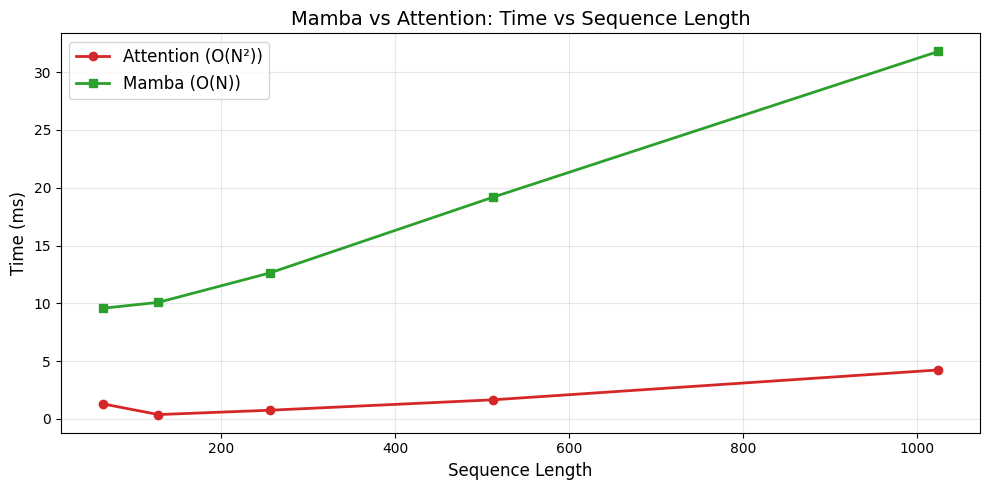

At N=1024: Attention 4.2ms vs Mamba 31.8ms


In [4]:
# Compare: Mamba (O(N)) vs Attention (O(N²)) scaling
d = 64
mamba_block = Mamba2Block(d_model=d)
attn_layer = nn.MultiheadAttention(d, num_heads=4, batch_first=True)

seq_lengths = [64, 128, 256, 512, 1024]
mamba_times, attn_times = [], []

for N in seq_lengths:
    x = torch.randn(1, N, d)

    # Mamba
    start = time.perf_counter()
    for _ in range(5):
        _ = mamba_block(x)
    mamba_times.append((time.perf_counter() - start) / 5 * 1000)

    # Attention
    start = time.perf_counter()
    for _ in range(5):
        _ = attn_layer(x, x, x)
    attn_times.append((time.perf_counter() - start) / 5 * 1000)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(seq_lengths, attn_times, 'o-', label='Attention (O(N²))', linewidth=2, color='tab:red')
ax.plot(seq_lengths, mamba_times, 's-', label='Mamba (O(N))', linewidth=2, color='tab:green')
ax.set_xlabel('Sequence Length', fontsize=12)
ax.set_ylabel('Time (ms)', fontsize=12)
ax.set_title('Mamba vs Attention: Time vs Sequence Length', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"At N=1024: Attention {attn_times[-1]:.1f}ms vs Mamba {mamba_times[-1]:.1f}ms")

## 6. Why Hybrid?

**Mamba alone has a weakness:** precise associative recall.

Given: "The capital of France is Paris. The capital of Japan is Tokyo. ... [500 tokens later]
What is the capital of France?"

- **Attention** excels: directly looks up the token where "France" and "Paris" co-occur
- **Mamba** struggles: must encode this fact into its fixed-size state vector and recall it later

**Solution:** Use Mamba for most layers (cheap, handles general sequence processing) and
sprinkle in attention layers at key depths for precise lookup. The 3:1 ratio means
only ~25% of layers are attention — 75% cheaper than a pure Transformer.

In [5]:
class AttentionBlock(nn.Module):
    """Standard multi-head attention block (used sparsely in the hybrid)."""

    def __init__(self, d_model, n_heads=4, dropout=0.0):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)

    def forward(self, x):
        residual = x
        x = self.norm(x)
        out, _ = self.attn(x, x, x)
        return out + residual


def build_hybrid_backbone(d_model, n_cycles=2, n_experts=16, top_k=4,
                          expert_ff_dim=32, latent_dim=32):
    """
    Build Nemotron-3 Super's hybrid block pattern.
    Each cycle: Mamba → MoE → Mamba → Attention → Mamba → MoE
    """
    layers = []
    layer_types = []

    for cycle in range(n_cycles):
        # Mamba
        layers.append(Mamba2Block(d_model))
        layer_types.append('Mamba')
        # LatentMoE
        layers.append(LatentMoELayer(d_model, latent_dim, expert_ff_dim, n_experts, top_k))
        layer_types.append('LatentMoE')
        # Mamba
        layers.append(Mamba2Block(d_model))
        layer_types.append('Mamba')
        # Attention
        layers.append(AttentionBlock(d_model))
        layer_types.append('Attention')
        # Mamba
        layers.append(Mamba2Block(d_model))
        layer_types.append('Mamba')
        # LatentMoE
        layers.append(LatentMoELayer(d_model, latent_dim, expert_ff_dim, n_experts, top_k))
        layer_types.append('LatentMoE')

    return nn.ModuleList(layers), layer_types


# We'll define LatentMoELayer next, then come back to build the full model

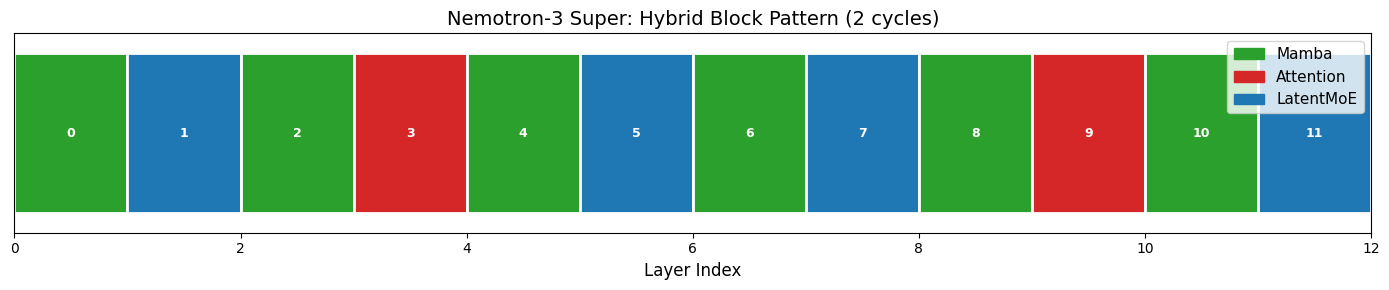

  Mamba: 6/12 layers (50%)
  LatentMoE: 4/12 layers (33%)
  Attention: 2/12 layers (17%)


In [6]:
# Visualize the block pattern
pattern = ['Mamba', 'LatentMoE', 'Mamba', 'Attention', 'Mamba', 'LatentMoE'] * 2  # 2 cycles
colors_map = {'Mamba': 'tab:green', 'Attention': 'tab:red', 'LatentMoE': 'tab:blue'}

fig, ax = plt.subplots(figsize=(14, 3))
for i, layer_type in enumerate(pattern):
    ax.barh(0, 1, left=i, color=colors_map[layer_type], edgecolor='white', linewidth=2)
    ax.text(i + 0.5, 0, f'{i}', ha='center', va='center', fontsize=9, fontweight='bold', color='white')

# Legend
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=c, label=l) for l, c in colors_map.items()]
ax.legend(handles=handles, loc='upper right', fontsize=11)

ax.set_xlim(0, len(pattern))
ax.set_ylim(-0.5, 0.5)
ax.set_xlabel('Layer Index', fontsize=12)
ax.set_title('Nemotron-3 Super: Hybrid Block Pattern (2 cycles)', fontsize=14)
ax.set_yticks([])
plt.tight_layout()
plt.show()

from collections import Counter
counts = Counter(pattern)
total = len(pattern)
for lt, c in counts.items():
    print(f"  {lt}: {c}/{total} layers ({100*c/total:.0f}%)")

## 7. LatentMoE

Standard MoE routes tokens at the full $d_{model}$ dimension. **LatentMoE** first projects
tokens into a smaller latent space, then routes and computes:

```
Standard MoE:  token (d=4096) → Router → Expert FFN (4096→16384→4096) → output
LatentMoE:     token (d=4096) → ↓project (d=512) → Router → Expert FFN (512→2048→512) → ↑project (d=4096) → output
```

**Result:** Each expert is 8x smaller. At the same compute budget, you can have **4x more
experts** — finer-grained specialization. The router also operates on lower-dimensional
input, making routing cheaper.

In [7]:
class LatentMoELayer(nn.Module):
    """
    LatentMoE: project tokens to latent space before expert routing and computation.
    Enables 4x more experts at the same computational cost.
    """

    def __init__(self, d_model, latent_dim, expert_ff_dim, n_experts=32, top_k=4):
        super().__init__()
        self.n_experts = n_experts
        self.top_k = top_k

        # Project to/from latent space
        self.down_proj = nn.Linear(d_model, latent_dim, bias=False)
        self.up_proj = nn.Linear(latent_dim, d_model, bias=False)

        # Router operates in latent space (cheaper)
        self.gate = nn.Linear(latent_dim, n_experts, bias=False)

        # Expert FFNs operate in latent space (much smaller)
        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(latent_dim, expert_ff_dim, bias=False),
                nn.SiLU(),
                nn.Linear(expert_ff_dim, latent_dim, bias=False),
            )
            for _ in range(n_experts)
        ])

        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        residual = x
        x = self.norm(x)
        B, N, D = x.shape

        # Project to latent space
        z = self.down_proj(x)  # [B, N, latent_dim]

        # Route in latent space
        router_logits = self.gate(z)
        top_k_logits, indices = torch.topk(router_logits, self.top_k, dim=-1)
        weights = torch.softmax(top_k_logits, dim=-1)

        # Expert computation in latent space
        output = torch.zeros_like(z)
        for k in range(self.top_k):
            expert_idx = indices[:, :, k]
            expert_weight = weights[:, :, k].unsqueeze(-1)
            for i in range(self.n_experts):
                mask = (expert_idx == i)
                if mask.any():
                    output[mask] += (expert_weight[mask] * self.experts[i](z[mask])).squeeze(-2)

        # Project back to full dimension
        return self.up_proj(output) + residual


# Demo
latent_moe = LatentMoELayer(d_model=128, latent_dim=32, expert_ff_dim=64, n_experts=16, top_k=4)
x = torch.randn(1, 8, 128)
out = latent_moe(x)
print(f"LatentMoE: {x.shape} → {out.shape}")
print(f"Latent dim: 32 (vs model dim: 128 = 4x compression)")
print(f"Parameters: {sum(p.numel() for p in latent_moe.parameters()):,}")

LatentMoE: torch.Size([1, 8, 128]) → torch.Size([1, 8, 128])
Latent dim: 32 (vs model dim: 128 = 4x compression)
Parameters: 74,496


In [8]:
# Compare: Standard MoE vs LatentMoE at same compute budget
d_model = 256
expert_ff = 512  # standard expert FFN size
latent_dim = 64  # 4x compression
latent_expert_ff = 128  # smaller expert in latent space

# Standard MoE: 8 large experts at full dimension
std_expert_params = 2 * d_model * expert_ff  # one expert
std_total = 8 * std_expert_params

# LatentMoE: 32 small experts in latent space + projections
latent_expert_params = 2 * latent_dim * latent_expert_ff  # one latent expert
proj_params = d_model * latent_dim * 2  # down + up projections
latent_total = 32 * latent_expert_params + proj_params

print(f"Same compute budget comparison:")
print(f"  Standard MoE: 8 experts × {std_expert_params:,} = {std_total:,} params")
print(f"  LatentMoE:    32 experts × {latent_expert_params:,} + {proj_params:,} proj = {latent_total:,} params")
print(f"\n  LatentMoE: 4x more experts ({32} vs {8}) for {latent_total/std_total:.1f}x the params")
print(f"  But active compute per token is similar (top-4 of 32 ≈ top-2 of 8 in FLOPs)")

Same compute budget comparison:
  Standard MoE: 8 experts × 262,144 = 2,097,152 params
  LatentMoE:    32 experts × 16,384 + 32,768 proj = 557,056 params

  LatentMoE: 4x more experts (32 vs 8) for 0.3x the params
  But active compute per token is similar (top-4 of 32 ≈ top-2 of 8 in FLOPs)


## 8. Multi-Token Prediction with Speculative Decoding

Like DeepSeek-V3, Nemotron uses MTP — but with a twist: the MTP heads **double as a
draft model** for speculative decoding at inference.

**Training:** Extra heads predict tokens $t+2, t+3, ...$ providing richer gradients.

**Inference:** The MTP heads generate draft tokens in parallel. The main model then
verifies all drafts in a single forward pass, accepting correct ones and rejecting wrong
ones. This gives up to **3x wall-clock speedup** for free — no separate draft model needed.

All MTP heads share weights for parameter efficiency.

In [9]:
class MTPWithSpeculativeDraft(nn.Module):
    """Multi-Token Prediction heads that double as a speculative draft model."""

    def __init__(self, d_model, vocab_size, n_draft_tokens=3):
        super().__init__()
        self.n_draft = n_draft_tokens

        # Main prediction head
        self.main_head = nn.Linear(d_model, vocab_size, bias=False)

        # Shared draft head (one set of weights, applied iteratively)
        self.draft_proj = nn.Linear(d_model, d_model, bias=False)
        self.draft_head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, hidden_states, targets=None, mtp_lambda=0.3):
        """Training: returns main logits + MTP loss."""
        main_logits = self.main_head(hidden_states)

        if targets is None or not self.training:
            return main_logits, 0.0

        # Main next-token loss
        main_loss = F.cross_entropy(
            main_logits[:, :-1].reshape(-1, main_logits.size(-1)),
            targets[:, 1:].reshape(-1)
        )

        # Draft token losses (shared weights, applied iteratively)
        draft_loss = 0.0
        h = hidden_states
        for d in range(2, 2 + self.n_draft):
            h = self.draft_proj(h)  # shared projection
            draft_logits = self.draft_head(h)
            if targets.size(1) > d:
                draft_loss += F.cross_entropy(
                    draft_logits[:, :-d].reshape(-1, draft_logits.size(-1)),
                    targets[:, d:].reshape(-1)
                )

        return main_logits, main_loss + mtp_lambda * draft_loss

    def speculative_decode(self, hidden_state):
        """
        Inference: generate draft tokens from the MTP heads.
        Returns main prediction + n_draft speculative predictions.
        """
        # Main token
        main_logits = self.main_head(hidden_state)  # [1, 1, vocab]
        main_token = main_logits.argmax(-1)  # [1, 1]

        # Draft tokens (fast, from shared head)
        draft_tokens = []
        h = hidden_state
        for _ in range(self.n_draft):
            h = self.draft_proj(h)
            draft_logits = self.draft_head(h)
            draft_tokens.append(draft_logits.argmax(-1))

        return main_token, draft_tokens


# Demo
mtp = MTPWithSpeculativeDraft(d_model=64, vocab_size=100, n_draft_tokens=3)

# Training mode
mtp.train()
hidden = torch.randn(1, 16, 64)
targets = torch.randint(0, 100, (1, 16))
logits, loss = mtp(hidden, targets)
print(f"Training: logits {logits.shape}, loss {loss.item():.4f}")

# Inference mode: speculative decoding
mtp.eval()
h = torch.randn(1, 1, 64)  # single position
main_tok, drafts = mtp.speculative_decode(h)
print(f"Speculative: main={main_tok.item()}, drafts={[d.item() for d in drafts]}")
print(f"→ 1 main + {len(drafts)} draft tokens in one pass (verify in next forward)")

Training: logits torch.Size([1, 16, 100]), loss 9.1368
Speculative: main=39, drafts=[73, 42, 8]
→ 1 main + 3 draft tokens in one pass (verify in next forward)


## 9. NVFP4: Native 4-bit Training

DeepSeek-V3 pushed training to FP8. Nemotron goes further with **native FP4 training** —
the model learns within 4-bit constraints from the first gradient update.

| Format | Bits | Memory/param | Use in Nemotron-3 | Speedup vs FP8 |
|---|---|---|---|---|
| FP32 | 32 | 4B | Optimizer states | — |
| BF16 | 16 | 2B | Master weights | — |
| FP8 | 8 | 1B | N/A (DeepSeek uses this) | — |
| **NVFP4** | **4** | **0.5B** | **All matmuls (forward + backward)** | **4x on Blackwell** |

**Key difference from post-training quantization:** The model is trained natively in FP4.
It never sees FP16/FP32 matrix multiplications during training. The loss landscape adapts
to 4-bit arithmetic from the start, resulting in better quality than quantizing after training.

For a 120B model:
- FP32: 480 GB
- BF16: 240 GB
- FP8: 120 GB
- **FP4: 60 GB** (fits on a single 80GB GPU for inference!)

## 10. Full Model Assembly

In [10]:
class Nemotron3Super(nn.Module):
    """
    Scaled-down Nemotron-3 Super architecture.
    Hybrid Mamba-Transformer with LatentMoE and MTP.
    """

    def __init__(self, vocab_size=1000, d_model=128, n_cycles=2,
                 n_experts=16, top_k=4, latent_dim=32, expert_ff_dim=64,
                 n_draft_tokens=2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)

        # Build hybrid backbone
        self.layers, self.layer_types = build_hybrid_backbone(
            d_model, n_cycles, n_experts, top_k, expert_ff_dim, latent_dim
        )

        self.norm = nn.LayerNorm(d_model)
        self.mtp = MTPWithSpeculativeDraft(d_model, vocab_size, n_draft_tokens)

    def forward(self, input_ids, targets=None):
        x = self.embed(input_ids)

        for layer in self.layers:
            x = layer(x)

        x = self.norm(x)
        logits, mtp_loss = self.mtp(x, targets)
        return logits, mtp_loss


# Create mini Nemotron-3 Super
model = Nemotron3Super(
    vocab_size=1000, d_model=128, n_cycles=2,
    n_experts=16, top_k=4, latent_dim=32, expert_ff_dim=64,
    n_draft_tokens=2
)

tokens = torch.randint(0, 1000, (1, 16))
targets = torch.randint(0, 1000, (1, 16))

model.train()
logits, loss = model(tokens, targets)

total_params = sum(p.numel() for p in model.parameters())
print(f"Mini Nemotron-3 Super:")
print(f"  Layers: {len(model.layers)} ({', '.join(model.layer_types[:6])}...)")
print(f"  Input:  {tokens.shape}")
print(f"  Output: {logits.shape}")
print(f"  MTP loss: {loss.item():.4f}")
print(f"  Total parameters: {total_params:,}")

Mini Nemotron-3 Super:
  Layers: 12 (Mamba, LatentMoE, Mamba, Attention, Mamba, LatentMoE...)
  Input:  torch.Size([1, 16])
  Output: torch.Size([1, 16, 1000])
  MTP loss: 11.2599
  Total parameters: 1,874,176


In [11]:
# Architecture summary
print("=" * 60)
print("Nemotron-3 Super Architecture Summary (Mini Version)")
print("=" * 60)

print(f"\n{'Layer Type':<15s} {'Count':>6s} {'Params (each)':>15s}")
print(f"{'-'*36}")

from collections import Counter
type_counts = Counter(model.layer_types)
for lt, count in type_counts.items():
    # Find first layer of this type
    idx = model.layer_types.index(lt)
    layer_params = sum(p.numel() for p in model.layers[idx].parameters())
    print(f"{lt:<15s} {count:>6d} {layer_params:>15,}")

embed_params = sum(p.numel() for p in model.embed.parameters())
mtp_params = sum(p.numel() for p in model.mtp.parameters())
print(f"{'Embedding':<15s} {'1':>6s} {embed_params:>15,}")
print(f"{'MTP heads':<15s} {'1':>6s} {mtp_params:>15,}")
print(f"{'-'*36}")
print(f"{'TOTAL':<15s} {'':>6s} {total_params:>15,}")

Nemotron-3 Super Architecture Summary (Mini Version)

Layer Type       Count   Params (each)
------------------------------------
Mamba                6         173,824
LatentMoE            4          74,496
Attention            2          66,304
Embedding            1         128,000
MTP heads            1         272,384
------------------------------------
TOTAL                        1,874,176


### Mini Model Comparison

| | Nemotron-3 Super | DeepSeek-V3 |
|---|---|---|
| Sequence processing | Mamba (O(N)) | Attention (O(N²)) |
| Attention layers | 2 of 12 (17%) | 4 of 4 (100%) |
| MoE type | LatentMoE | DeepSeekMoE |
| Expert routing dim | Latent (32) | Full (128) |
| Position encoding | N/A (Mamba) | Decoupled RoPE |
| Normalization | LayerNorm | RMSNorm |
| Long context | 1M (Mamba) | 128K (attention) |

## 11. Nemotron-3 vs DeepSeek-V3

| Innovation | DeepSeek-V3 | Nemotron-3 Super |
|---|---|---|
| **Sequence processing** | All attention (MLA) | **Hybrid: 75% Mamba + 25% Attention** |
| **KV compression** | MLA (low-rank KV latent) | **Mamba state (no KV cache for SSM layers)** |
| **MoE design** | DeepSeekMoE (256 experts, shared + routed) | **LatentMoE (tokens compressed before routing)** |
| **Training precision** | FP8 | **FP4 (native)** |
| **Context window** | 128K | **1M** |
| **MTP** | Yes (1 extra head) | **Yes + native speculative decoding** |
| **Total params** | 671B | 120B |
| **Active params** | 37B | 12B |

Two fundamentally different approaches to efficient LLMs:
- **DeepSeek:** Keep attention everywhere, make it cheaper (MLA + Flash Attention)
- **Nemotron:** Replace most attention with Mamba, keep attention only where needed

## 12. Key Takeaways

1. **Mamba enables linear-time long context.** By replacing 75% of attention layers with O(N) SSM layers, Nemotron supports 1M tokens — 8x longer than attention-based models.

2. **Hybrid > pure Mamba or pure Transformer.** Mamba excels at general sequence processing but struggles with precise recall. Sprinkling in attention layers at key depths gives the best of both worlds.

3. **LatentMoE = more experts at same cost.** Compressing tokens before expert routing enables 4x more experts at the same compute, giving finer-grained specialization.

4. **MTP heads are free speculative decoders.** The same prediction heads used during training become a draft model at inference, giving up to 3x speedup with no additional parameters.

5. **FP4 is the next frontier.** Training natively in 4-bit (not just quantizing after) cuts memory and compute by another 2x vs FP8. Requires hardware support (NVIDIA Blackwell).

6. **SSMs and Transformers are converging.** The trend is toward hybrid architectures that combine the strengths of both — linear-time sequence processing with precise associative recall.

### Prerequisite Notebooks

| Concept | Notebook |
|---|---|
| Transformer basics | `05_Papers/03_Attention_Is_All_You_Need` |
| MoE | `05_Papers/04_Mixture_of_Experts` |
| RoPE | `05_Papers/02_RoPE` |
| Mixed precision | `03_Training/02_Mixed_Precision_Training` |
| DeepSeek-V3 (compare) | `07_Model_Replications/01_DeepSeek_V3` |

### Further Reading

- NVIDIA (2026). *Nemotron-3 Super Technical Report.* https://arxiv.org/abs/2512.20856
- Gu & Dao (2023). *Mamba: Linear-Time Sequence Modeling with Selective State Spaces.* https://arxiv.org/abs/2312.00752
- Dao & Gu (2024). *Transformers are SSMs.* https://arxiv.org/abs/2405.21060